In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

os.chdir(r'D:\End-to-end-ML\Customer-Risk-Escalation-Engine')

warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm




In [21]:
X_train = pd.read_csv('notebooks/data/processed/X_train.csv')
X_test  = pd.read_csv('notebooks/data/processed/X_test.csv')
y_train = pd.read_csv('notebooks/data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('notebooks/data/processed/y_test.csv').squeeze()

print("Data loaded ✅")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

Data loaded ✅
X_train : (150000, 26)
X_test  : (50000, 26)


In [22]:
mlflow.set_experiment("customer_escalation_tabular")
print("MLflow experiment set ✅")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

2026/06/03 01:26:13 INFO mlflow.tracking.fluent: Experiment with name 'customer_escalation_tabular' does not exist. Creating a new experiment.


MLflow experiment set ✅
Tracking URI: sqlite:///D:/End-to-end-ML/Customer-Risk-Escalation-Engine/mlflow.db


In [23]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "f1_score"  : round(f1_score(y_test, y_pred), 4), # type: ignore
        "precision" : round(precision_score(y_test, y_pred), 4), # type: ignore
        "recall"    : round(recall_score(y_test, y_pred), 4), # type: ignore
        "roc_auc"   : round(roc_auc_score(y_test, y_pred_prob), 4)
    }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {metrics['accuracy']}")
    print(f"  F1 Score  : {metrics['f1_score']}")
    print(f"  Precision : {metrics['precision']}")
    print(f"  Recall    : {metrics['recall']}")
    print(f"  ROC AUC   : {metrics['roc_auc']}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred))

    return metrics, y_pred, y_pred_prob

In [24]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Escalated', 'Escalated'],
        yticklabels=['Not Escalated', 'Escalated']
    )
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, model_name, top_n=20):
    importance = pd.DataFrame({
        'feature'   : feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=importance,
        x='importance',
        y='feature',
        palette='viridis'
    )
    plt.title(f'{model_name} — Top {top_n} Important Features', fontsize=13)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return importance


def plot_roc_curve(y_test, y_pred_prob, model_name):
    RocCurveDisplay.from_predictions(
        y_test,
        y_pred_prob,
        name=model_name
    )
    plt.title(f'ROC Curve — {model_name}')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
    plt.tight_layout()
    plt.show()

2026/06/03 01:26:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 01:26:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Decision Tree — Evaluation Results
  Accuracy  : 0.5016
  F1 Score  : 0.5716
  Precision : 0.5028
  Recall    : 0.6623
  ROC AUC   : 0.5002
              precision    recall  f1-score   support

           0       0.50      0.34      0.40     24895
           1       0.50      0.66      0.57     25105

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.49     50000
weighted avg       0.50      0.50      0.49     50000

MLflow run logged ✅


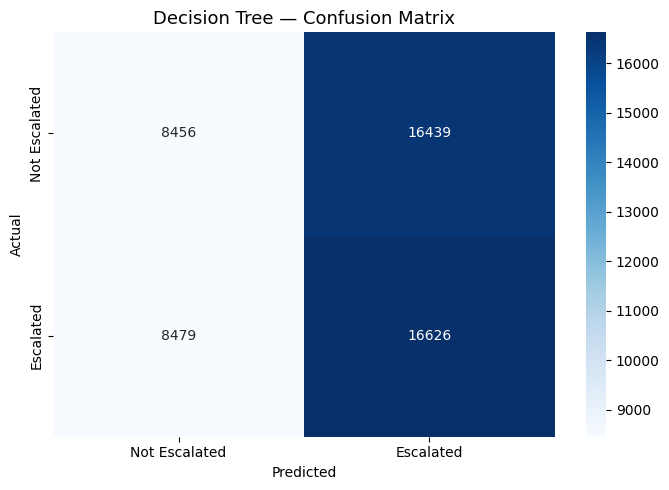

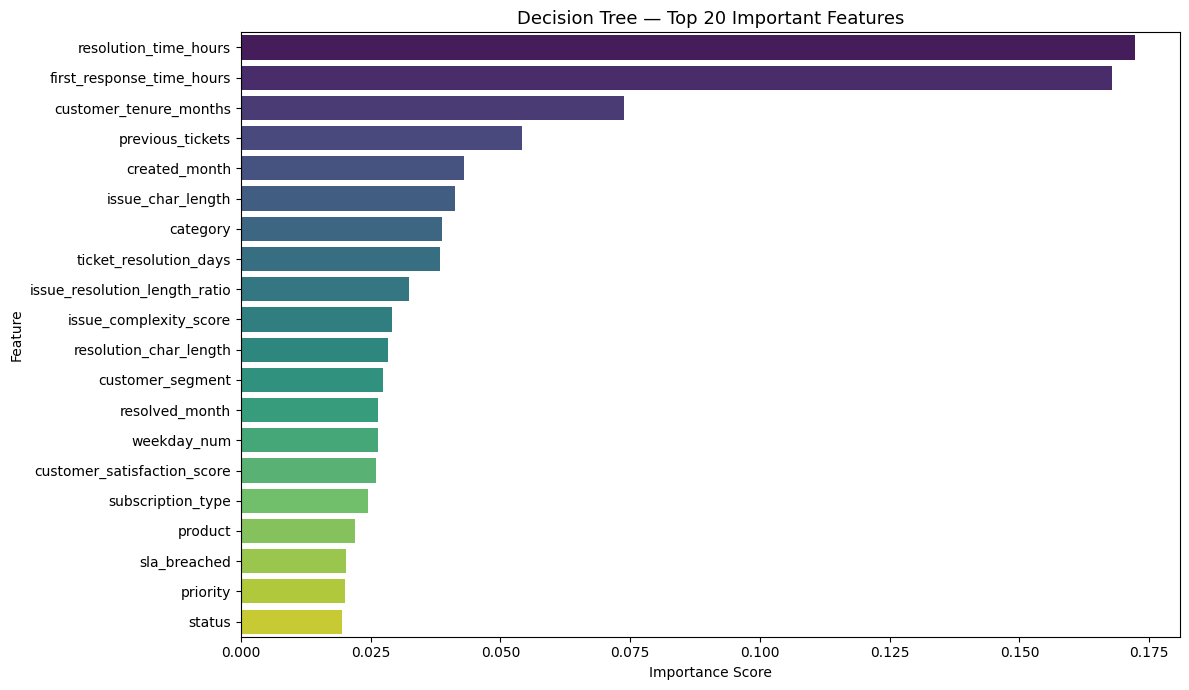

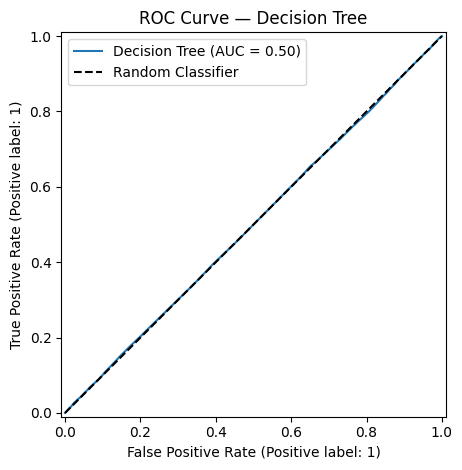

In [25]:
dt_params = {
    "max_depth"        : 10,
    "min_samples_leaf" : 50,
    "random_state"     : 42
}

with mlflow.start_run(run_name="Decision_Tree"):

    dt_model = DecisionTreeClassifier(**dt_params)
    dt_model.fit(X_train, y_train)

    dt_metrics, dt_pred, dt_prob = evaluate_model(
        dt_model, X_test, y_test,
        model_name="Decision Tree"
    )

    mlflow.log_params(dt_params)
    mlflow.log_metrics(dt_metrics)
    mlflow.sklearn.log_model(dt_model, "decision_tree")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, dt_pred, "Decision Tree")
plot_feature_importance(dt_model, X_train.columns.tolist(), "Decision Tree")
plot_roc_curve(y_test, dt_prob, "Decision Tree")

2026/06/03 01:26:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 01:26:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Random Forest — Evaluation Results
  Accuracy  : 0.5029
  F1 Score  : 0.5396
  Precision : 0.5043
  Recall    : 0.5801
  ROC AUC   : 0.5009
              precision    recall  f1-score   support

           0       0.50      0.42      0.46     24895
           1       0.50      0.58      0.54     25105

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000

MLflow run logged ✅


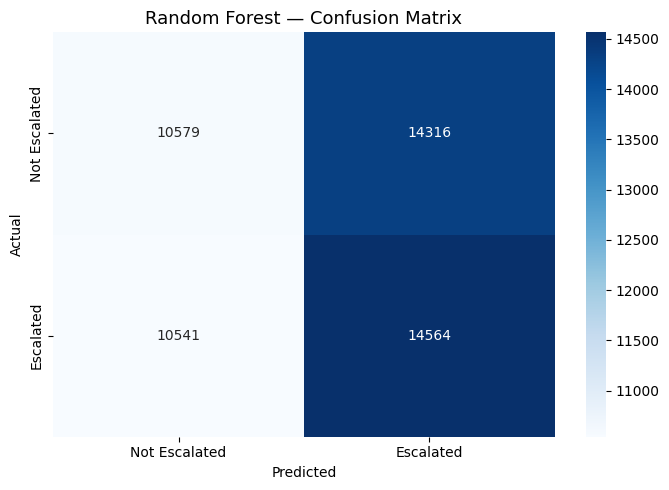

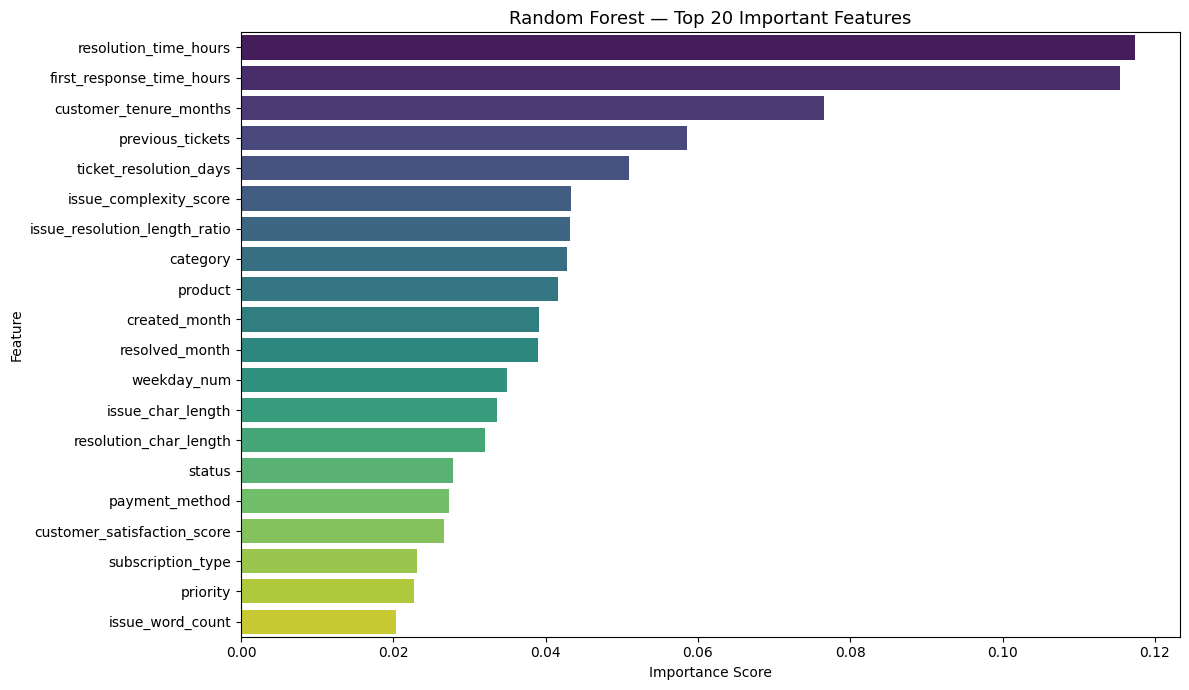

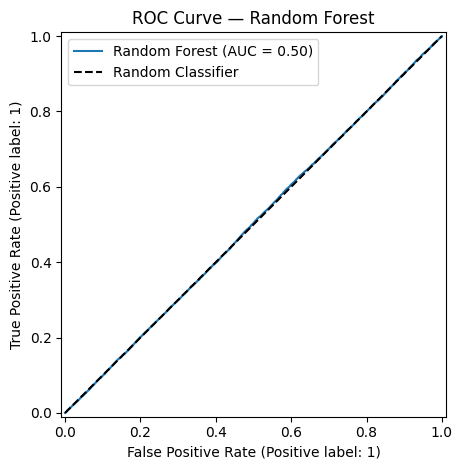

In [26]:
rf_params = {
    "n_estimators" : 200,
    "max_depth"    : 10,
    "n_jobs"       : -1,
    "random_state" : 42
}

with mlflow.start_run(run_name="Random_Forest"):

    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train, y_train)

    rf_metrics, rf_pred, rf_prob = evaluate_model(
        rf_model, X_test, y_test,
        model_name="Random Forest"
    )

    mlflow.log_params(rf_params)
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(rf_model, "random_forest")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, rf_pred, "Random Forest")
plot_feature_importance(rf_model, X_train.columns.tolist(), "Random Forest")
plot_roc_curve(y_test, rf_prob, "Random Forest")

2026/06/03 01:26:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Baseline — Evaluation Results
  Accuracy  : 0.5046
  F1 Score  : 0.52
  Precision : 0.5063
  Recall    : 0.5344
  ROC AUC   : 0.5041
              precision    recall  f1-score   support

           0       0.50      0.47      0.49     24895
           1       0.51      0.53      0.52     25105

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000

MLflow run logged ✅


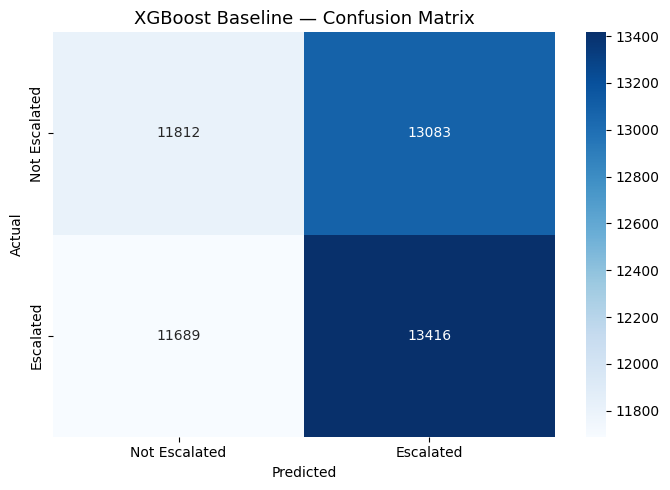

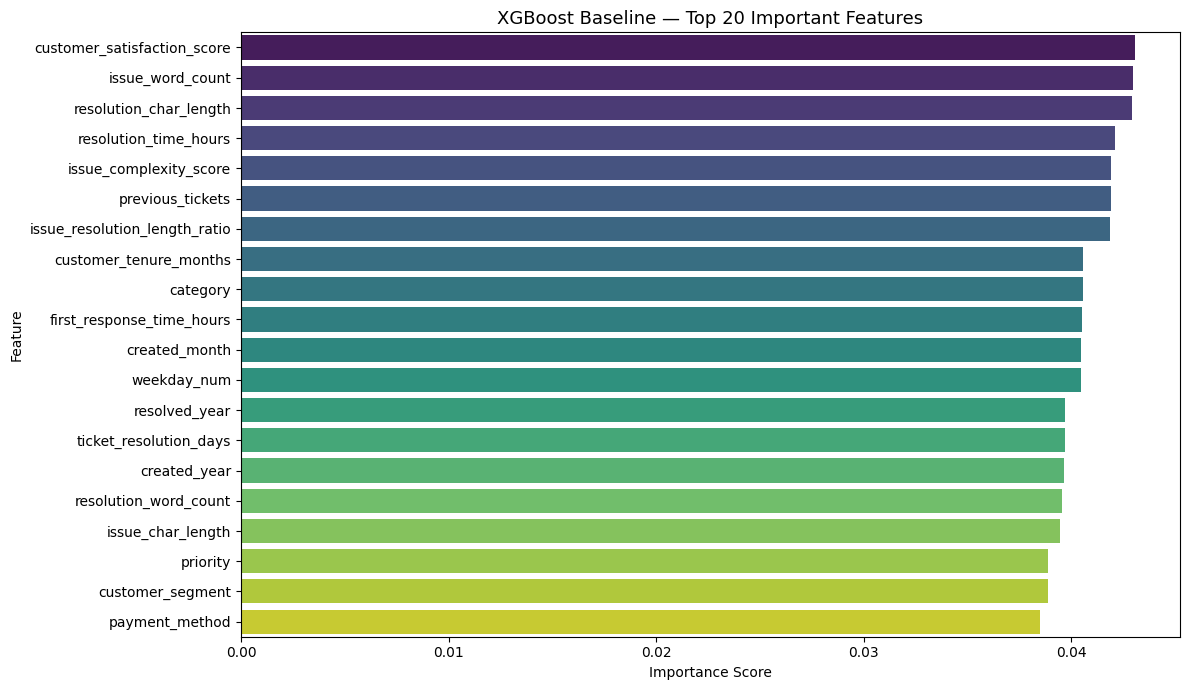

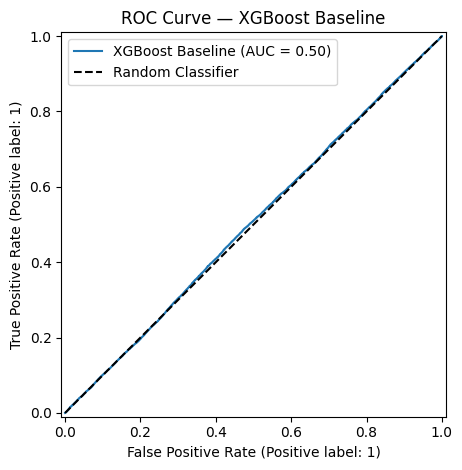

In [27]:
xgb_baseline_params = {
    "n_estimators"      : 100,
    "max_depth"         : 6,
    "learning_rate"     : 0.1,
    "random_state"      : 42,
    "eval_metric"       : "logloss",
    "use_label_encoder" : False
}

with mlflow.start_run(run_name="XGBoost_Baseline"):

    xgb_baseline = XGBClassifier(**xgb_baseline_params)
    xgb_baseline.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_base_metrics, xgb_base_pred, xgb_base_prob = evaluate_model(
        xgb_baseline, X_test, y_test,
        model_name="XGBoost Baseline"
    )

    mlflow.log_params(xgb_baseline_params)
    mlflow.log_metrics(xgb_base_metrics)
    mlflow.xgboost.log_model(xgb_baseline, "xgboost_baseline")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, xgb_base_pred, "XGBoost Baseline")
plot_feature_importance(xgb_baseline, X_train.columns.tolist(), "XGBoost Baseline")
plot_roc_curve(y_test, xgb_base_prob, "XGBoost Baseline")

2026/06/03 01:26:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  XGBoost Tuned — Evaluation Results
  Accuracy  : 0.5027
  F1 Score  : 0.516
  Precision : 0.5045
  Recall    : 0.5279
  ROC AUC   : 0.503
              precision    recall  f1-score   support

           0       0.50      0.48      0.49     24895
           1       0.50      0.53      0.52     25105

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000

MLflow run logged ✅


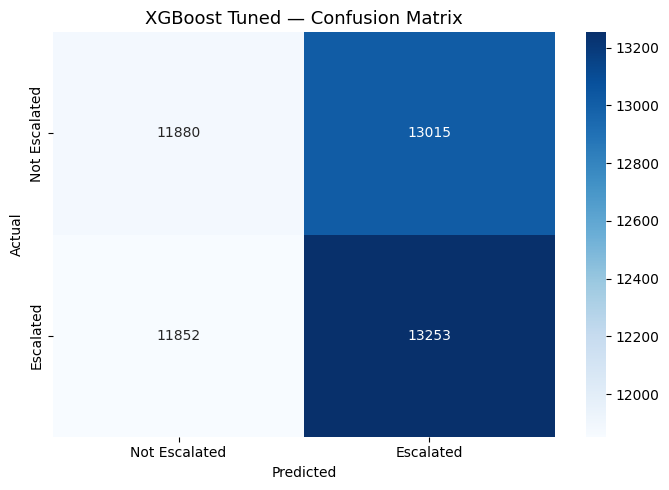

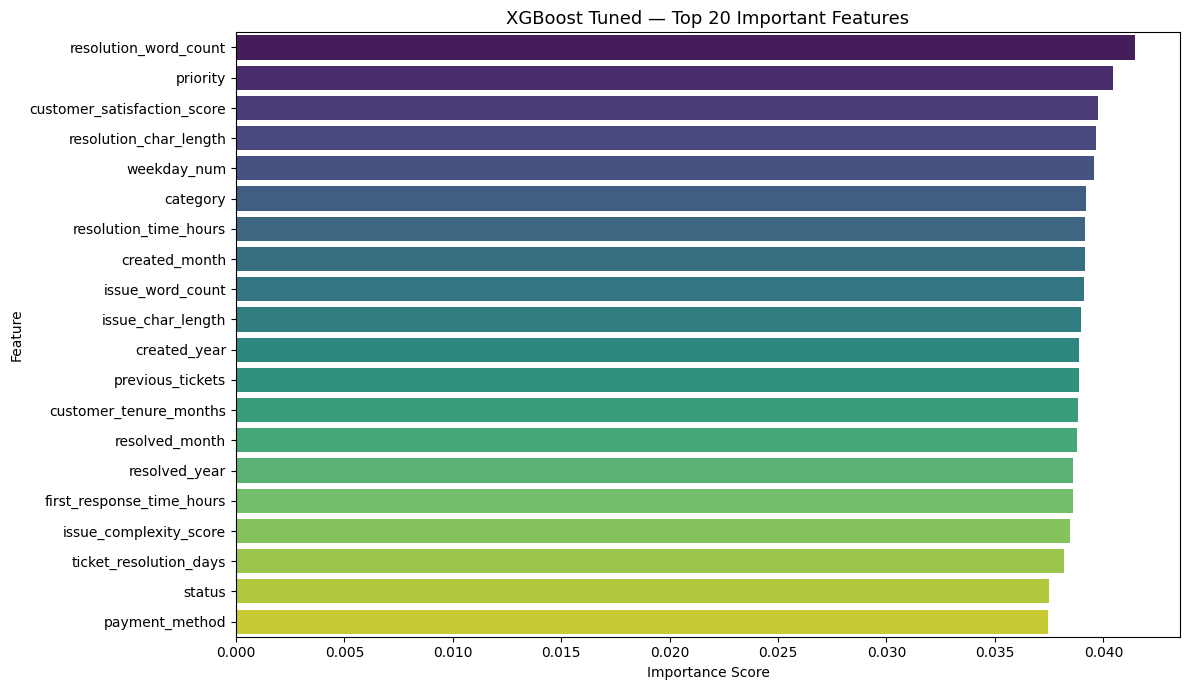

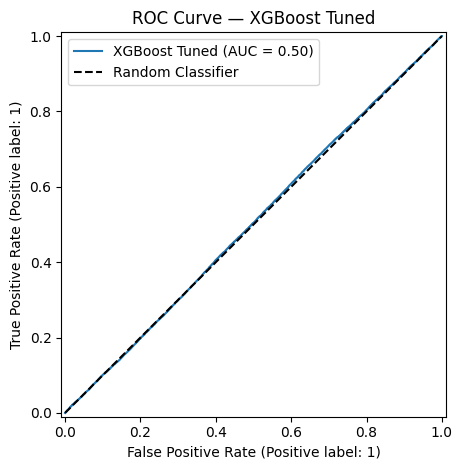

In [28]:
xgb_tuned_params = {
    "n_estimators"      : 300,
    "max_depth"         : 5,
    "learning_rate"     : 0.05,
    "min_child_weight"  : 3,
    "subsample"         : 0.8,
    "colsample_bytree"  : 0.8,
    "random_state"      : 42,
    "eval_metric"       : "logloss",
    "use_label_encoder" : False
}

with mlflow.start_run(run_name="XGBoost_Tuned"):

    xgb_tuned = XGBClassifier(**xgb_tuned_params)
    xgb_tuned.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
        xgb_tuned, X_test, y_test,
        model_name="XGBoost Tuned"
    )

    mlflow.log_params(xgb_tuned_params)
    mlflow.log_metrics(xgb_tuned_metrics)
    mlflow.xgboost.log_model(xgb_tuned, "xgboost_tuned")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, xgb_tuned_pred, "XGBoost Tuned")
plot_feature_importance(xgb_tuned, X_train.columns.tolist(), "XGBoost Tuned")
plot_roc_curve(y_test, xgb_tuned_prob, "XGBoost Tuned")

2026/06/03 01:27:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 01:27:05 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  LightGBM — Evaluation Results
  Accuracy  : 0.5028
  F1 Score  : 0.5187
  Precision : 0.5046
  Recall    : 0.5336
  ROC AUC   : 0.5039
              precision    recall  f1-score   support

           0       0.50      0.47      0.49     24895
           1       0.50      0.53      0.52     25105

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000

MLflow run logged ✅


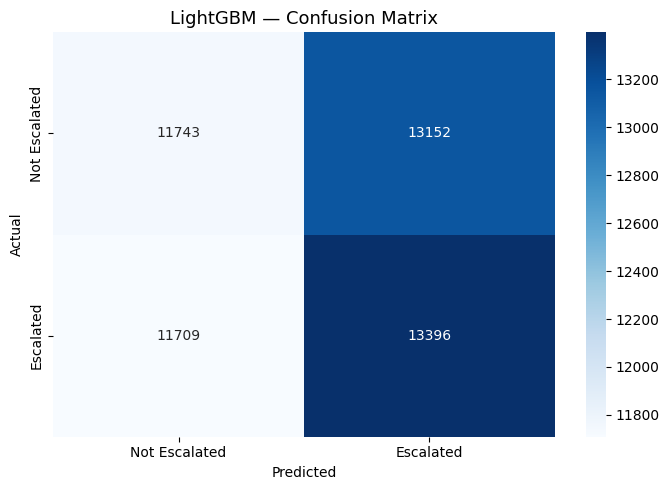

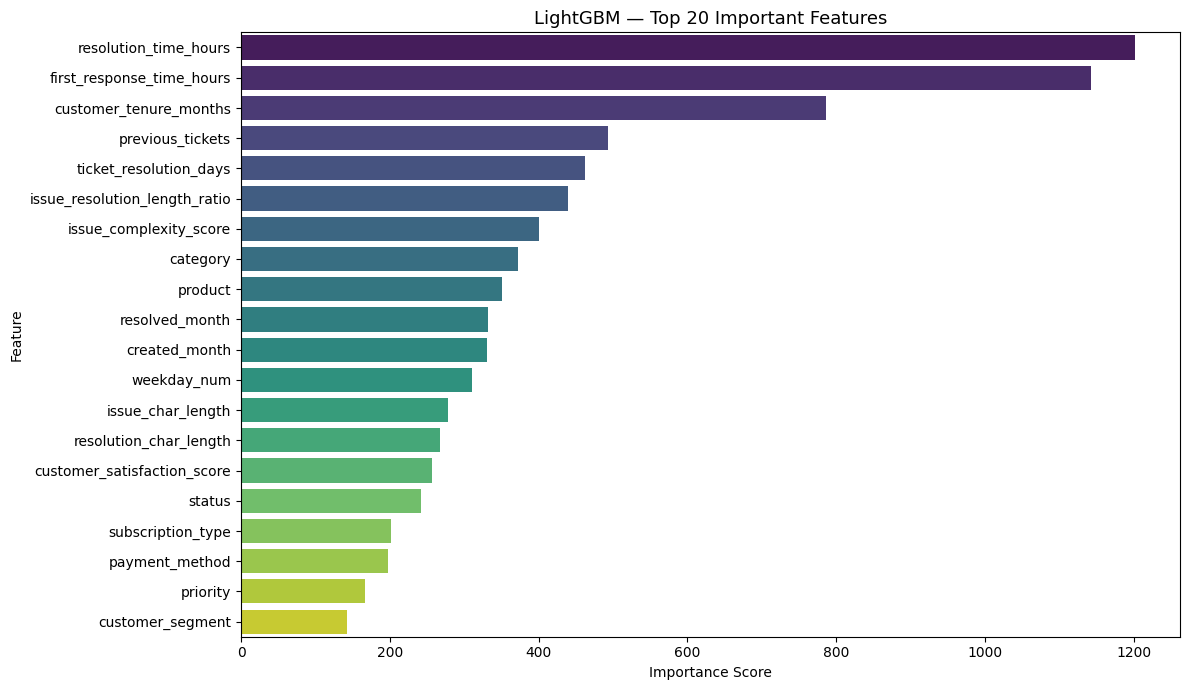

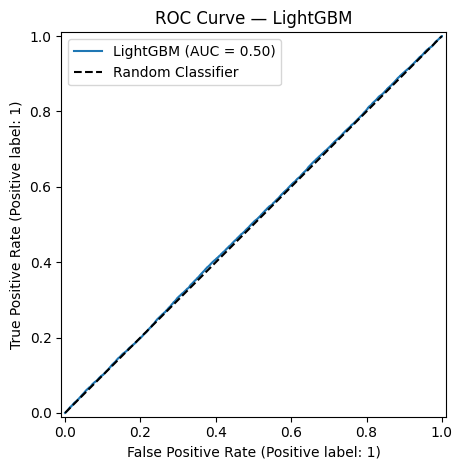

In [29]:
lgbm_params = {
    "n_estimators"  : 300,
    "max_depth"     : 5,
    "learning_rate" : 0.05,
    "subsample"     : 0.8,
    "random_state"  : 42,
    "n_jobs"        : -1,
    "verbose"       : -1
}

with mlflow.start_run(run_name="LightGBM"):

    lgbm_model = LGBMClassifier(**lgbm_params)
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)]
    )

    lgbm_metrics, lgbm_pred, lgbm_prob = evaluate_model(
        lgbm_model, X_test, y_test,
        model_name="LightGBM"
    )

    mlflow.log_params(lgbm_params)
    mlflow.log_metrics(lgbm_metrics)
    mlflow.lightgbm.log_model(lgbm_model, "lightgbm")

    print("MLflow run logged ✅")

plot_confusion_matrix(y_test, lgbm_pred, "LightGBM")
plot_feature_importance(lgbm_model, X_train.columns.tolist(), "LightGBM")
plot_roc_curve(y_test, lgbm_prob, "LightGBM")